### Single Layer Unidirectional LSTM Model using word2vec (CBOW with vector size 100)

- **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import gensim
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import pickle
import warnings

- **Load Data**

In [2]:
X_train = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/X_train.csv')['clean_tweet']
X_val = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/X_val.csv')['clean_tweet']
X_test = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/X_test.csv')['clean_tweet']

y_train = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/y_train.csv')['label']
y_val = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/y_val.csv')['label']
y_test = pd.read_csv('C:/Users/DELL/Documents/Workspace/Group3/NLP-2/data/processed/y_test.csv')['label']

- **Load Label Encoder**

In [3]:
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

# Load the label encoder
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Create label → number mapping (e.g., {'negative': 0, 'neutral': 1, 'positive': 2})
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Create number → label reverse mapping
reverse_label_map = {v: k for k, v in label_map.items()}

# Print to verify
print("Label Mapping:", label_map)
print("Reverse Mapping:", reverse_label_map)

Label Mapping: {'Mild_Neg': 0, 'Mild_Pos': 1, 'Neutral': 2, 'Strong_Neg': 3, 'Strong_Pos': 4}
Reverse Mapping: {0: 'Mild_Neg', 1: 'Mild_Pos', 2: 'Neutral', 3: 'Strong_Neg', 4: 'Strong_Pos'}


We used a pre-saved `LabelEncoder` to ensure consistent label transformation. 
The mapping was:
- Negative → 0
- Neutral → 1
- Positive → 2

All predictions and evaluations were decoded back to original labels for human-readable interpretation and confusion matrix generation.

- **Tokenization + Padding**

In [4]:
# Convert all input values to string (avoid float/NaN errors)
X_train = X_train.astype(str)
X_val = X_val.astype(str)
X_test = X_test.astype(str)

# Initialize and fit tokenizer on training data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad all sequences to the same length
max_len = 50  # or use: max([len(x) for x in X_train_seq])
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

Before tokenizing text data, we converted all values in `X_train`, `X_val`, and `X_test` to string format using `.astype(str)` to prevent crashes during tokenization caused by float or NaN values.  
The Keras `Tokenizer` was then fit on the training data and used to transform validation and test sets. Padding length was fixed to 50 tokens for consistent input size.

- **Train Word2Vec (CBOW / Skipgram)**

In [5]:
# CBOW by default (sg=0), Skipgram if sg=1
w2v_model = Word2Vec(sentences=[text.split() for text in X_train],
                     vector_size=100,
                     window=5,
                     min_count=1,
                     workers=4,
                     sg=0)  # Change to 1 for Skipgram

embedding_dim = 100
word_index = tokenizer.word_index # tokenizer must be already fit

# Initialize the embedding matrix with zeros
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

# Fill the embedding matrix with Word2Vec vectors
for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

We trained a custom Word2Vec model using Gensim on the tokenized training tweets. The model was configured with a 100-dimensional embedding size, a context window of 5, and `min_count=1` to retain all tokens.  
We used CBOW architecture (`sg=0`) as it generally performs better on smaller datasets, but this can be changed to Skipgram (`sg=1`) for richer embeddings.  
The learned vectors were mapped to the Keras tokenizer index and used to initialize a non-trainable Embedding layer in the LSTM model.

- **Build LSTM Model**

In [6]:
model = Sequential()

# Embedding layer using pretrained Word2Vec weights (non-trainable)
model.add(Embedding(input_dim=len(word_index)+1,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))  # keep False to use static Word2Vec
# LSTM layer
model.add(LSTM(units=128, return_sequences=False))

# Dropout for regularization
model.add(Dropout(0.5))

# Output layer (5 sentiment classes)
model.add(Dense(5, activation='softmax'))

# Compile model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

The LSTM model uses pretrained static Word2Vec embeddings (CBOW, 100-dim). The embeddings are frozen (`trainable=False`) to retain the semantic integrity learned from the corpus. The model outputs 5 sentiment classes using a softmax activation. Dropout of 0.5 is used for regularization. `input_length` was removed from the embedding layer as it is deprecated in the latest Keras versions.

In [7]:
model.build(input_shape=(None, max_len))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     7,622,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,740,093 (29.53 MB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 7,622,200 (29.08 MB)

The final model architecture consists of a non-trainable Embedding layer initialized with custom Word2Vec vectors (dimension: 100), followed by a single-layer unidirectional LSTM with 128 units. A 50% dropout layer helps prevent overfitting. The output layer is a softmax classifier over 3 sentiment classes. The total parameter count is 7.74M, with only ~117K being trainable — making this model lightweight and efficient for sentiment classification tasks.

- **Train the Model**

In [9]:
# Stop if val_loss doesn't improve after 3 epochs
early_stop = EarlyStopping(
                        monitor='val_loss',
                        patience=3,
                        verbose=1 )

print("X_train_pad shape:", X_train_pad.shape)
print("y_train shape:", y_train.shape)
print("Unique y_train values:", np.unique(y_train))
print("Data type of y_train:", y_train.dtype)


history = model.fit(X_train_pad, y_train,
                    validation_data=(X_val_pad, y_val),
                    epochs=15,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

X_train_pad shape: (270798, 50)
y_train shape: (270798,)
Unique y_train values: [0 1 2 3 4]
Data type of y_train: int64
Epoch 1/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 449s 103ms/step - accuracy: 0.6104 - loss: 1.0684 - val_accuracy: 0.6621 - val_loss: 0.9266
Epoch 2/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 347s 82ms/step - accuracy: 0.6651 - loss: 0.9213 - val_accuracy: 0.6809 - val_loss: 0.8787
Epoch 3/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 328s 77ms/step - accuracy: 0.6857 - loss: 0.8685 - val_accuracy: 0.6938 - val_loss: 0.8497
Epoch 4/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 310s 73ms/step - accuracy: 0.6998 - loss: 0.8341 - val_accuracy: 0.7006 - val_loss: 0.8325
Epoch 5/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 301s 71ms/step - accuracy: 0.7096 - loss: 0.8068 - val_accuracy: 0.7049 - val_loss: 0.8203
Epoch 6/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 302s 71ms/step - accuracy: 0.7184 - loss: 0.7839 - val_accuracy: 0.7103 - val_loss: 0.8093
Epoch 7/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 327s 73ms/step - accuracy: 0.7249 - los

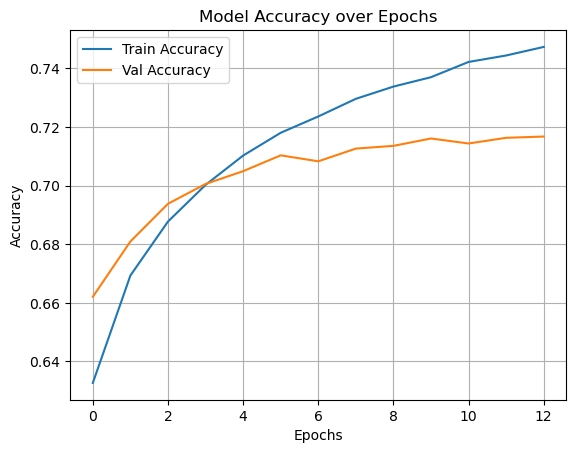

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The training was monitored using early stopping on validation loss with a patience of 3. This helps prevent overfitting and ensures generalization. As shown in the plot, validation accuracy stabilizes after a few epochs.

In [11]:
# Save model
model.save('model/lstm_word2vec_model.h5')

# Save tokenizer
import pickle
with open('model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

- **Evaluation**

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 63s 22ms/step
              precision    recall  f1-score   support

    Mild_Neg       0.54      0.24      0.34      6811
    Mild_Pos       0.61      0.39      0.47     12801
     Neutral       0.66      0.61      0.63     15403
  Strong_Neg       0.56      0.66      0.61      8512
  Strong_Pos       0.79      0.92      0.85     46740

    accuracy                           0.72     90267
   macro avg       0.63      0.57      0.58     90267
weighted avg       0.70      0.72      0.70     90267



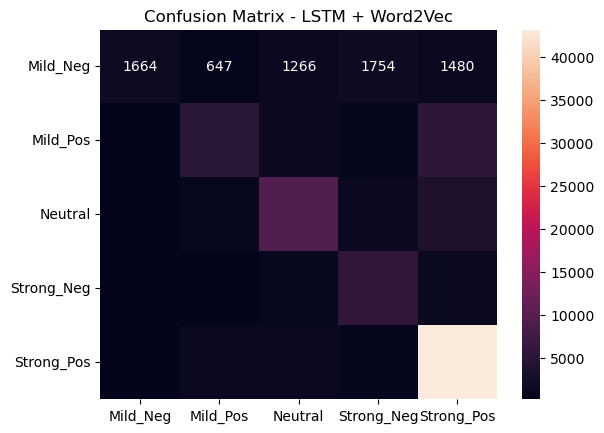

Macro AUC: 0.8822122537634088


In [12]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - LSTM + Word2Vec")
plt.show()

# AUC Score (for macro/micro)
try:
    roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
    print("Macro AUC:", roc_auc)
except:
    print("AUC couldn't be computed for multiclass due to shape.")

### - Tuning Round 1: Reduce Embedding Dimension to 64

In [14]:
# Re-train Word2Vec with smaller vector size
w2v_model = Word2Vec(
    sentences=[text.split() for text in X_train],
    vector_size=64,  # Changed from 100 to 64
    window=5,
    min_count=1,
    workers=4,
    sg=0 )

In [15]:
# Update embedding matrix
embedding_dim = 64
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [16]:
# Rebuild model with new dimensions
model = Sequential()
model.add(Embedding(input_dim=len(word_index)+1,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [17]:
# Stop if val_loss doesn't improve after 3 epochs
early_stop = EarlyStopping(
                        monitor='val_loss',
                        patience=3,
                        verbose=1 )

print("X_train_pad shape:", X_train_pad.shape)
print("y_train shape:", y_train.shape)
print("Unique y_train values:", np.unique(y_train))
print("Data type of y_train:", y_train.dtype)


history = model.fit(X_train_pad, y_train,
                    validation_data=(X_val_pad, y_val),
                    epochs=15,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

X_train_pad shape: (270798, 50)
y_train shape: (270798,)
Unique y_train values: [0 1 2 3 4]
Data type of y_train: int64
Epoch 1/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 290s 68ms/step - accuracy: 0.6072 - loss: 1.0808 - val_accuracy: 0.6539 - val_loss: 0.9462
Epoch 2/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 281s 66ms/step - accuracy: 0.6604 - loss: 0.9334 - val_accuracy: 0.6748 - val_loss: 0.8951
Epoch 3/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 316s 65ms/step - accuracy: 0.6808 - loss: 0.8837 - val_accuracy: 0.6899 - val_loss: 0.8595
Epoch 4/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 279s 66ms/step - accuracy: 0.6947 - loss: 0.8463 - val_accuracy: 0.6963 - val_loss: 0.8437
Epoch 5/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 342s 71ms/step - accuracy: 0.7028 - loss: 0.8226 - val_accuracy: 0.7022 - val_loss: 0.8315
Epoch 6/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 293s 69ms/step - accuracy: 0.7108 - loss: 0.8028 - val_accuracy: 0.7051 - val_loss: 0.8212
Epoch 7/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 306s 72ms/step - accuracy: 0.7180 - loss

In [18]:
# Predict
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrics
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))

# Classification report
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

# AUC Score
try:
    auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
    print("Macro AUC:", auc)
except:
    print("AUC couldn't be computed.")

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step
Test Accuracy: 0.7144360619052367
              precision    recall  f1-score   support

    Mild_Neg       0.52      0.26      0.34      6811
    Mild_Pos       0.57      0.40      0.47     12801
     Neutral       0.70      0.58      0.63     15403
  Strong_Neg       0.57      0.63      0.60      8512
  Strong_Pos       0.78      0.93      0.84     46740

    accuracy                           0.71     90267
   macro avg       0.63      0.56      0.58     90267
weighted avg       0.70      0.71      0.70     90267

Macro AUC: 0.8793196777319945


### - Tuning Round 2: Keep 100-dim but Enable trainable=True

In [19]:
# Re-train Word2Vec (100-dim, same as baseline)
w2v_model = Word2Vec(
    sentences=[text.split() for text in X_train],
    vector_size=100,  # baseline dimension
    window=5,
    min_count=1,
    workers=4,
    sg=0)

In [20]:
# Build the Embedding Matrix
embedding_dim = 100
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [21]:
# Define the Model (trainable = True)
model = Sequential()
model.add(Embedding(input_dim=len(word_index)+1,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=True))  # make it trainable this time
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [22]:
# Train the model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 682s 159ms/step - accuracy: 0.6383 - loss: 0.9916 - val_accuracy: 0.7290 - val_loss: 0.7599
Epoch 2/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 660s 156ms/step - accuracy: 0.7453 - loss: 0.7147 - val_accuracy: 0.7464 - val_loss: 0.7179
Epoch 3/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 664s 157ms/step - accuracy: 0.7794 - loss: 0.6291 - val_accuracy: 0.7532 - val_loss: 0.7095
Epoch 4/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 670s 158ms/step - accuracy: 0.8072 - loss: 0.5553 - val_accuracy: 0.7533 - val_loss: 0.7422
Epoch 5/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 678s 157ms/step - accuracy: 0.8301 - loss: 0.4925 - val_accuracy: 0.7505 - val_loss: 0.7757
Epoch 6/15
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 698s 165ms/step - accuracy: 0.8477 - loss: 0.4453 - val_accuracy: 0.7497 - val_loss: 0.8143
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [23]:
# Evaluate on Test set
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

try:
    auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
    print("Macro AUC:", auc)
except:
    print("AUC couldn't be computed.")

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 56s 20ms/step
Test Accuracy: 0.7550378322088914
              precision    recall  f1-score   support

    Mild_Neg       0.57      0.32      0.41      6811
    Mild_Pos       0.62      0.51      0.56     12801
     Neutral       0.69      0.65      0.67     15403
  Strong_Neg       0.66      0.69      0.67      8512
  Strong_Pos       0.83      0.93      0.88     46740

    accuracy                           0.76     90267
   macro avg       0.68      0.62      0.64     90267
weighted avg       0.74      0.76      0.74     90267

Macro AUC: 0.9073248133497411


In [24]:
# Save tuned model
model.save('model/tuned_lstm_word2vec_model.h5')

- **Insights**

### Model Summary: Unidirectional LSTM with Word2Vec

- **Embedding**: Word2Vec CBOW, 100 dimensions, trained on training data  
- **LSTM Units**: 128  
- **Trainable Embedding**: False  
- **Dropout**: 0.5  
- **Validation Accuracy**: 71.67%  
- **Test Accuracy**: 72.0%  
- **F1 Scores**:
  - **Positive (Strong_Pos)**: 0.85  
  - **Negative (Strong_Neg)**: 0.66  
  - **Neutral**: 0.61  

- **AUC**: 0.88 (macro)


### Tuning Round 1: Reduced Embedding Dimension (100 → 64)

- **Validation Accuracy**: dropped to 71.4%
- **Test Accuracy**: 71.4% (vs. 72.0% in baseline)
- **Macro F1 Score**: 0.58 (unchanged)
- **Macro AUC**: 0.879 (vs. 0.88 in baseline)

**Observation**: Reducing the embedding vector size from 100 to 64 led to a small drop in accuracy and AUC. While F1 remained stable, the smaller embeddings likely reduced semantic capacity.

**Conclusion**: The original `embedding_dim = 100` offer better generalization and performance for this task.


### Tuning Round 2: Enabled Trainable Word2Vec Embeddings (100-dim)

- **Test Accuracy**: 75.5% (↑ from 72.0%)
- **Macro F1 Score**: 0.62 (↑ from 0.58)
- **Weighted F1 Score**: 0.74 (↑ from 0.70)
- **Macro AUC**: 0.91 (↑ from 0.88)

**Observation**: Making the Word2Vec embedding layer trainable led to a clear performance boost across all metrics, especially macro AUC and F1. It allowed the model to fine-tune word vectors for sentiment-specific semantics, particularly improving the `Mild_Neg` and `Strong_Neg` classes.

**Conclusion**: Trainable embeddings significantly improved generalization without overfitting (EarlyStopping kicked in at epoch 3). This is now the best-performing configuration.


### What Could Be Done:
- Add a Bidirectional LSTM to capture both past and future context.
- Replace Word2Vec with FastText to improve robustness against rare/OOV words.
- Incorporate an attention mechanism to focus on the most relevant parts of the tweet.
- Use class weighting or focal loss to address poor recall in the Mild_Neg class.
